In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
missing = (df.isnull().sum() / len(df)) * 100
missing.sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

In [7]:
df = df.drop(columns=['Cabin'])

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [9]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [10]:
df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

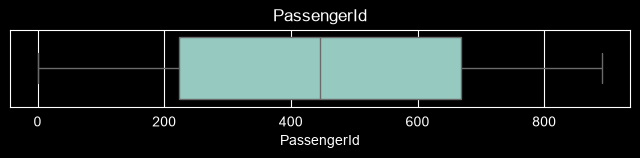

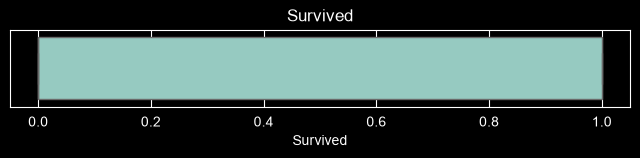

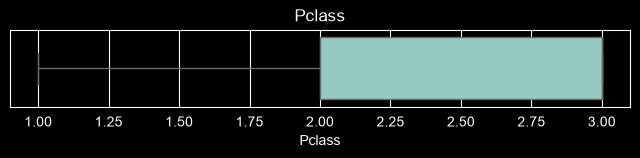

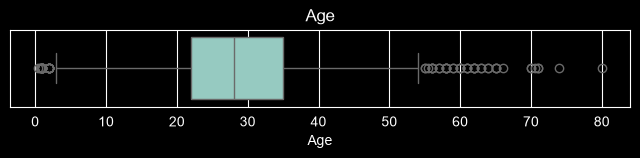

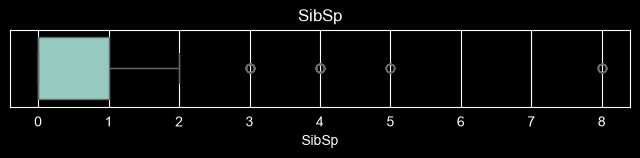

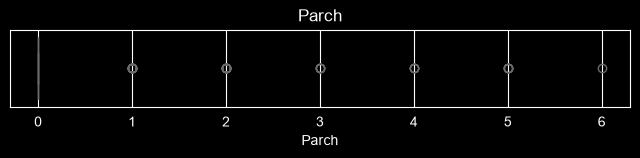

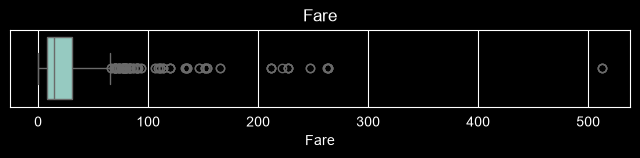

In [11]:
numeric_df = df.select_dtypes(include='number')
for col in numeric_df.columns:
    plt.figure(figsize=(8,1))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

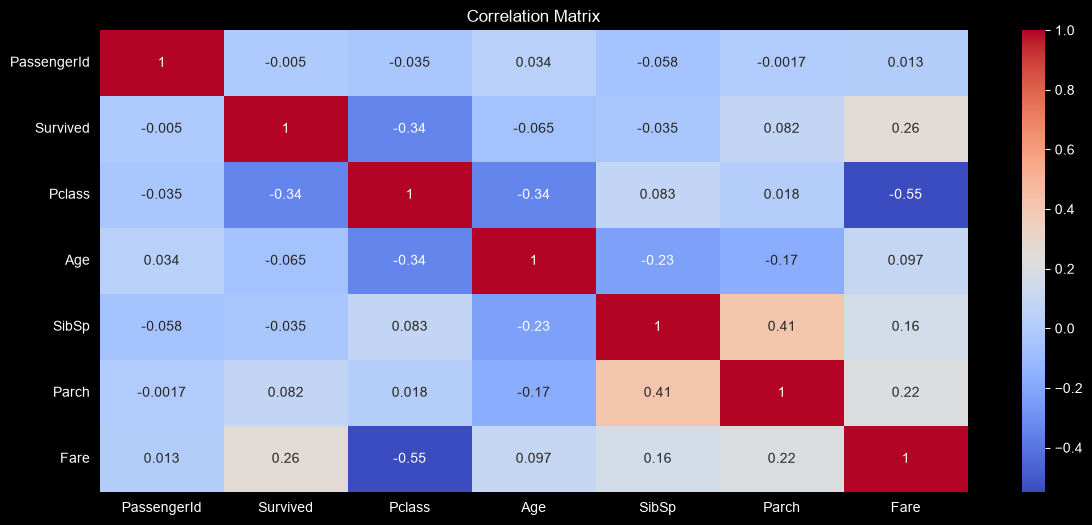

In [13]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(14,6))
sns.heatmap(corr, cmap='coolwarm',annot=True)
plt.title('Correlation Matrix')
plt.show()

In [16]:
gender_percentage = df['Sex'].value_counts(normalize=True) * 100
gender_percentage

Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64

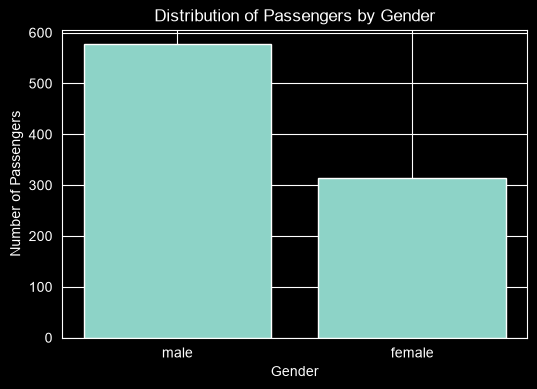

In [18]:
gender_count = df['Sex'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(gender_count.index, gender_count.values)

plt.title("Distribution of Passengers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

In [19]:
gender_count.index

Index(['male', 'female'], dtype='str', name='Sex')

In [20]:
gender_count.values


array([577, 314])

In [32]:
age_distribution = (
    df.groupby('Age')
      .size()
      .sort_values(ascending=False)
      .reset_index(name='age_count')
)

In [33]:
age_distribution

,Age,age_count
0,28.0,202
1,24.0,30
2,22.0,27
3,18.0,26
4,19.0,25
...,...,...
83,53.0,1
84,66.0,1
85,70.5,1
86,74.0,1


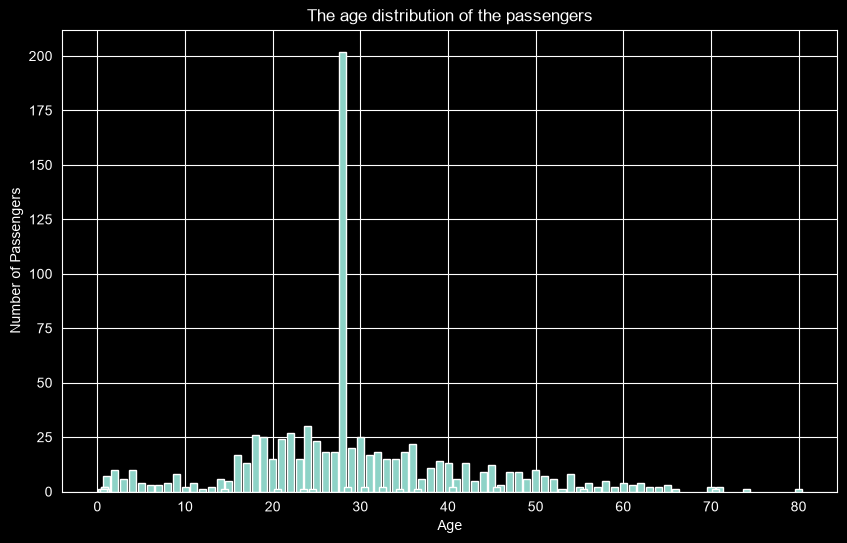

In [35]:
plt.figure(figsize=(10,6))

plt.bar(age_distribution['Age'],
        age_distribution['age_count'])

plt.title('The age distribution of the passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()